In [3]:
import numpy as np    
import matplotlib.pyplot as plt
%matplotlib inline    

from fizinfo import *

In [4]:
vonat_raw = GPS_to_num_kinem('vonat-Gyor-Komarom.csv', orig='first')
vonat = num_kinem_smooth_r(vonat_raw, 0.1, lam=50, err_report=True)

Adatsor pontosság: RMS=11.641; MAX=28.570
Eltérés          : RMS=1.615; MAX=11.326


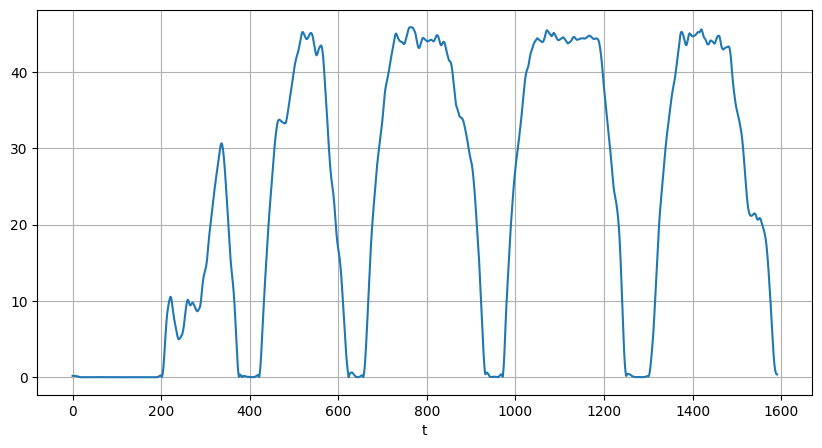

In [5]:
# a) Ábrázolja a vonat sebességének nagyságát az idő függvényében! 2p

vonat.calc_r_to_v()
vonat.calc_pathlength()
# Mivel a vonatnak van x és y irányú sebessége ezért vektor abszolút érték kell
vonat.v_abs = vect_abs(vonat.v)

fig=plt.figure(figsize=(10,5))  
ax1=plt.subplot(111)

ax1.plot(vonat.t,vonat.v_abs)
ax1.set_xlabel('t')

ax1.grid()

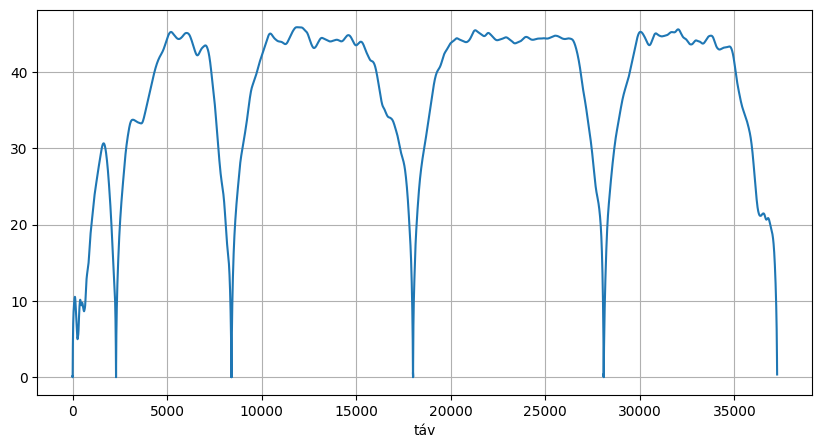

In [6]:
# a) Ábrázolja a vonat sebességének nagyságát az útvonalhossz függvényében! 2p

fig=plt.figure(figsize=(10,5))  
ax1=plt.subplot(111)

ax1.plot(vonat.pathlength,vonat.v_abs)
ax1.set_xlabel('táv')

ax1.grid()

In [7]:
# b) Állónak tekintjük azokat a szakaszokat, amikor a sebességnagysága 1 m/s-nál kisebb. 
# Hány másodpercig állt a vonat összesen? (3 p)

allo_hatar = 1 # m/s

dt = vonat.t[1:] - vonat.t[:-1] # lépésköz, azaz mennyi idő telt el két egymást követő mérés között

vonat_allt = vonat.v_abs[:-1] < allo_hatar # bool tömb maszk, hol igaz, hogy v < 1m/s

ossz_allas = dt[vonat_allt].sum() # csak a True helyeken lévő dt-k összege

print(f'A vonat összesen {ossz_allas:.2f} s ideig állt.')


A vonat összesen 395.50 s ideig állt.


A vonat összesen 567.60 s ideig ment gyorsabban. Négy ilyen szakasz volt.


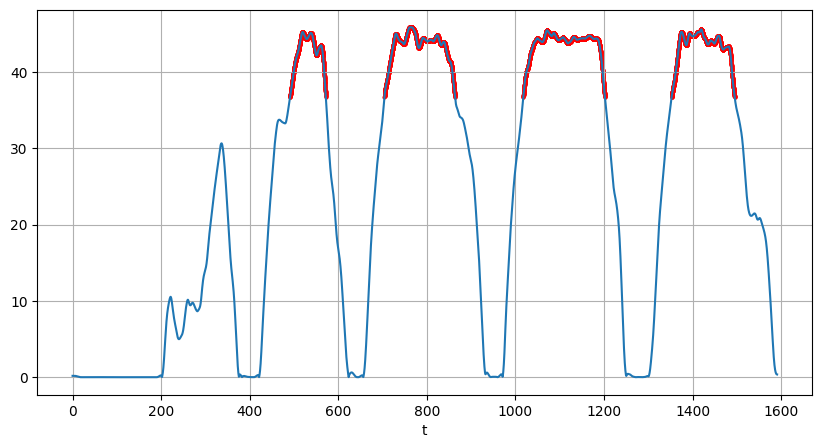

In [8]:
# c) Mennyi ideig haladt a vonat a maximális sebesség 80%-ánál nagyobb sebességgel 
# és hány ilyen nagy-sebességű szakasz volt? (4 p)

max_seb = vonat.v_abs.max()          # maximális sebesség
max_seb_80p = max_seb * 0.8          # küszöbérték: max 80%-a

vonat_gyorsabb_80p = vonat.v_abs[:-1] > max_seb_80p # bool maszk: hol v > küszöb

max_seb_80p_ossz_ido = dt[vonat_gyorsabb_80p].sum() # küszöb feletti dt-k összege

fig=plt.figure(figsize=(10,5))  
ax1=plt.subplot(111)

ax1.plot(vonat.t, vonat.v_abs)                        # sebességgrafikon idő függvényében
ax1.set_xlabel('t')
ax1.scatter(vonat.t[:-1][vonat_gyorsabb_80p],         # küszöb feletti pontok
            vonat.v_abs[:-1][vonat_gyorsabb_80p],     # pirossal kiemelve
            color='red', s=4)

ax1.grid()

print(f'A vonat összesen {max_seb_80p_ossz_ido:.2f} s ideig ment gyorsabban. Négy ilyen szakasz volt.')

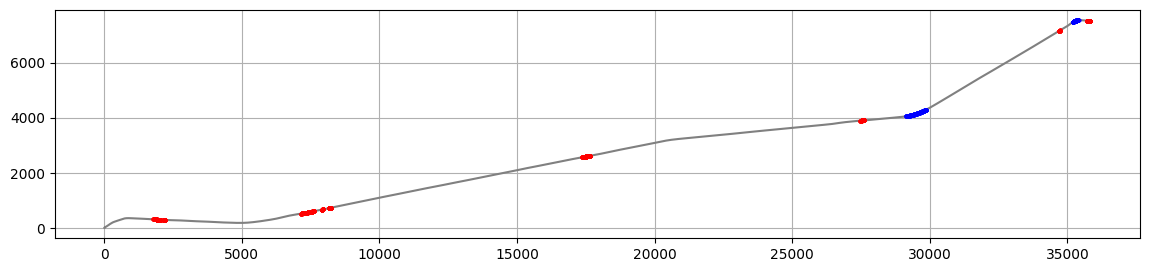

In [9]:
# d) Készítsen ábrát, melyen a vonat pályája szürke, és rajta pirossal az erős fékezési (0.8 m/s^2-nél erősebb), 
# kékkel az erős kanyarodási (0.7 m/s^2-nél erősebb) szakaszok vannak bejelölve.

fek_hatar = 0.8   # m/s^2, erős fékezés küszöbe
kan_hatar = 0.7   # m/s^2, erős kanyarodás küszöbe

eros_fekezes  = -vonat.a_t_abs > fek_hatar   # bool maszk: erős fékezés (a_t negatív fékezésnél)
eros_kanyar   = vonat.a_cp_abs > kan_hatar   # bool maszk: erős centripetális gyorsulás

fig=plt.figure(figsize=(14,4))  
ax1=plt.subplot(111)

ax1.plot(vonat.r[:,0], vonat.r[:,1], color="grey")  # a pályagörbe
ax1.scatter(vonat.r[eros_fekezes, 0], vonat.r[eros_fekezes, 1],
            color='red',  s=4, zorder=3)                     # erős fékezési szakaszok
ax1.scatter(vonat.r[eros_kanyar,  0], vonat.r[eros_kanyar,  1],
            color='blue', s=4, zorder=3)                     # erős kanyarodási szakaszok


ax1.set_aspect(aspect='equal')
ax1.grid()